1. HPO with different tree depths on Branin

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ConfigSpace import ConfigurationSpace, Configuration, Float
from smac import Scenario
from smac import HyperparameterOptimizationFacade as HPOFacade


SEED = 67
N_TRIALS = 75
DEPTHS = [2, 3, 4, 5, 6, 7,8,9,10]

def branin(x1, x2):
    a = 1.0
    b = 5.1 / (4 * np.pi**2)
    c = 5 / np.pi
    r = 6.0
    s = 10.0
    t = 1 / (8 * np.pi)

    return a * (x2 - b * x1**2 + c * x1 - r)**2 + s * (1 - t) * np.cos(x1) + s


def branin_eval(config: Configuration, seed: int = 0) -> float:
    x1 = config["x1"]
    x2 = config["x2"]
    return branin(x1, x2)


def make_configspace(seed: int = SEED) -> ConfigurationSpace:
    cs = ConfigurationSpace(seed=seed)
    cs.add(
        Float("x1", (-5, 10)),
        Float("x2", (0, 15)),
    )
    return cs


def run_one_split(depth: int):
    cs = make_configspace(SEED)

    scenario = Scenario(
        configspace=cs,
        deterministic=True,
        n_trials=N_TRIALS,
        seed=SEED,
        name=f"branin_hpo_rf_depth_{depth}",
        output_directory=Path("smac_output_rf_depth"),
    )

    model = HPOFacade.get_model(
        scenario=scenario,
        max_depth=depth,
    )

    smac = HPOFacade(
        scenario=scenario,
        target_function=branin_eval,
        model=model,
        overwrite=True,
    )

    incumbent = smac.optimize()
    incumbent_cost = smac.runhistory.get_cost(incumbent)

    trials = sorted(
        smac.runhistory.items(),
        key=lambda item: item[1].starttime,
    )

    costs = np.array([trial_value.cost for _, trial_value in trials], dtype=float)
    best_so_far = np.minimum.accumulate(costs)
    trial_numbers = np.arange(1, len(costs) + 1)

    convergence = pd.DataFrame({
        "depth": depth,
        "trial": trial_numbers,
        "cost": costs,
        "best_so_far": best_so_far,
    })

    return {
        "depth": depth,
        "smac": smac,
        "incumbent": incumbent,
        "incumbent_cost": incumbent_cost,
        "convergence": convergence,
    }


results = []

for max_split in DEPTHS:
    print(f"Running RF max_depth={max_split}")
    result = run_one_split(max_split)
    results.append(result)

    print("  incumbent:", dict(result["incumbent"]))
    print("  incumbent cost:", result["incumbent_cost"])
    print()


summary_df = pd.DataFrame({
    "depth": [r["depth"] for r in results],
    "incumbent_cost": [r["incumbent_cost"] for r in results],
})

print(summary_df)

Running RF max_depth=2
[INFO][abstract_initial_design.py:91] Reducing the number of initial configurations from 20 to 18 (max_ratio == 0.25).
[INFO][abstract_initial_design.py:143] Using 18 initial design configurations and 0 additional configurations.
[INFO][abstract_intensifier.py:313] Using only one seed for deterministic scenario.
[INFO][abstract_intensifier.py:523] Added config f23915 as new incumbent because there are no incumbents yet.


[INFO][abstract_intensifier.py:630] Added config bb7619 and rejected config f23915 as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][abstract_intensifier.py:630] Added config a2b59e and rejected config bb7619 as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][abstract_intensifier.py:630] Added config 992910 and rejected config a2b59e as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][abstract_intensifier.py:630] Added config e259fe and rejected config 992910 as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][abstract_intensifier.py:630] Added config fd03d9 and rejected config e259fe as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][abstract_intensifier.py:630] Added config e037a9 and rejected config fd03d9 as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][smbo.py:334] Finished 50 trials.
[INFO][abstr

KeyboardInterrupt: 

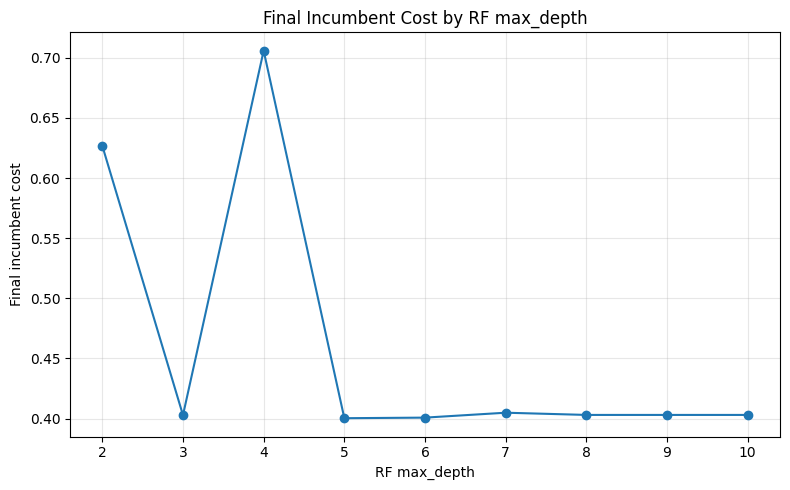

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    summary_df["depth"],
    summary_df["incumbent_cost"],
    marker="o",
)

ax.set_title("Final Incumbent Cost by RF max_depth")
ax.set_xlabel("RF max_depth")
ax.set_ylabel("Final incumbent cost")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

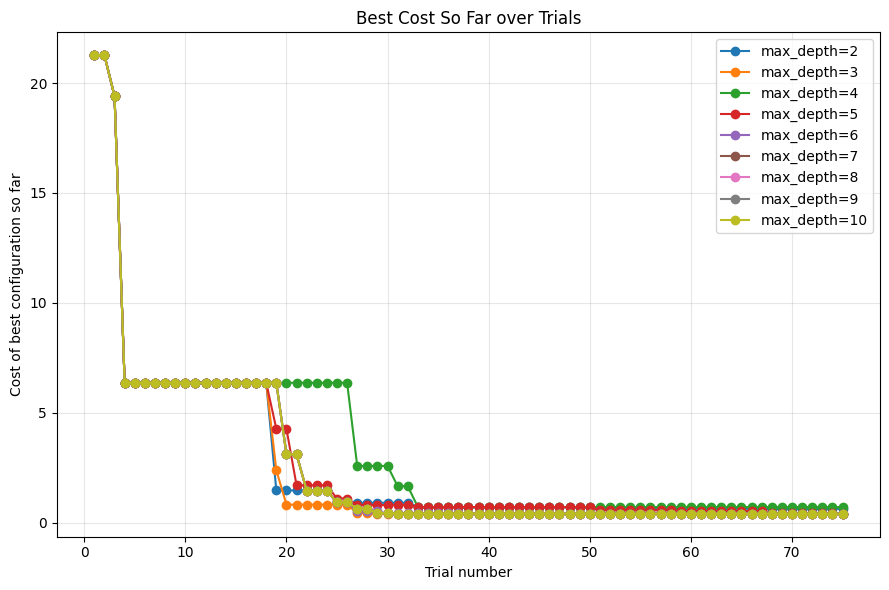

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

for result in results:
    df = result["convergence"]
    max_split = result["depth"]

    ax.plot(
        df["trial"],
        df["best_so_far"],
        marker="o",
        label=f"max_depth={max_split}",
    )

ax.set_title("Best Cost So Far over Trials")
ax.set_xlabel("Trial number")
ax.set_ylabel("Cost of best configuration so far")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
smac.validate()

2. HPOFacade for different min_split features

In [11]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ConfigSpace import ConfigurationSpace, Configuration, Float
from smac import Scenario
from smac import HyperparameterOptimizationFacade as HPOFacade


SEED = 67
N_TRIALS = 100
MIN_SPLITS = [2, 3, 4, 5, 6, 7]


def branin_eval(config: Configuration, seed: int = 0) -> float:
    x1 = config["x1"]
    x2 = config["x2"]
    return branin(x1, x2)


def make_configspace(seed: int = SEED) -> ConfigurationSpace:
    cs = ConfigurationSpace(seed=seed)
    cs.add(
        Float("x1", (-5, 10)),
        Float("x2", (0, 15)),
    )
    return cs


def run_one_min_split(min_split: int):
    cs = make_configspace(SEED)

    scenario = Scenario(
        configspace=cs,
        deterministic=True,
        n_trials=N_TRIALS,
        seed=SEED,
        name=f"branin_hpo_rf_min_split_{min_split}",
        output_directory=Path("smac_output_rf_min_split"),
    )

    model = HPOFacade.get_model(
        scenario=scenario,
        min_samples_split=min_split,
        # optional: fix these so only min_samples_split changes
        min_samples_leaf=1,
        max_depth=20,
    )

    smac = HPOFacade(
        scenario=scenario,
        target_function=branin_eval,
        model=model,
        overwrite=True,
    )

    incumbent = smac.optimize()
    incumbent_cost = smac.runhistory.get_cost(incumbent)

    trials = sorted(
        smac.runhistory.items(),
        key=lambda item: item[1].starttime,
    )

    costs = np.array([trial_value.cost for _, trial_value in trials], dtype=float)
    best_so_far = np.minimum.accumulate(costs)
    trial_numbers = np.arange(1, len(costs) + 1)

    convergence = pd.DataFrame({
        "min_samples_split": min_split,
        "trial": trial_numbers,
        "cost": costs,
        "best_so_far": best_so_far,
    })

    return {
        "min_samples_split": min_split,
        "smac": smac,
        "incumbent": incumbent,
        "incumbent_cost": incumbent_cost,
        "convergence": convergence,
    }


results = []

for min_split in MIN_SPLITS:
    print(f"Running RF min_samples_split={min_split}")
    result = run_one_min_split(min_split)
    results.append(result)

    print("  incumbent:", dict(result["incumbent"]))
    print("  incumbent cost:", result["incumbent_cost"])
    print()


summary_df = pd.DataFrame({
    "min_samples_split": [r["min_samples_split"] for r in results],
    "incumbent_cost": [r["incumbent_cost"] for r in results],
})

print(summary_df)

Running RF min_samples_split=2


[INFO][abstract_initial_design.py:143] Using 20 initial design configurations and 0 additional configurations.
[INFO][abstract_intensifier.py:313] Using only one seed for deterministic scenario.
[INFO][abstract_intensifier.py:523] Added config f23915 as new incumbent because there are no incumbents yet.
[INFO][abstract_intensifier.py:630] Added config bb7619 and rejected config f23915 as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][abstract_intensifier.py:630] Added config a2b59e and rejected config bb7619 as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][abstract_intensifier.py:630] Added config 4c4754 and rejected config a2b59e as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][abstract_intensifier.py:630] Added config 7fc2f1 and rejected config 4c4754 as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][abstract_intensifier.py:630] Added config fd03d9 and rej

In [23]:
from collections import Counter
print(next(iter(result["smac"].runhistory.items())))
print(result["smac"].runhistory.get_config(1).origin)

origins = []

for trialkey in result["smac"].runhistory.keys():
    origin = result["smac"].runhistory.get_config(trialkey.config_id).origin
    origins.append(origin)

print(Counter(origins))

(TrialKey(config_id=1, instance=None, seed=196930371, budget=None), TrialValue(cost=21.2680398154463, time=0.0, cpu_time=0.0, status=<StatusType.SUCCESS: 1>, starttime=1780749638.6058378, endtime=1780749638.6068385, additional_info={}))
Initial Design: Sobol
Counter({'Acquisition Function Maximizer: Local Search': 64, 'Initial Design: Sobol': 20, 'Random Search': 16})


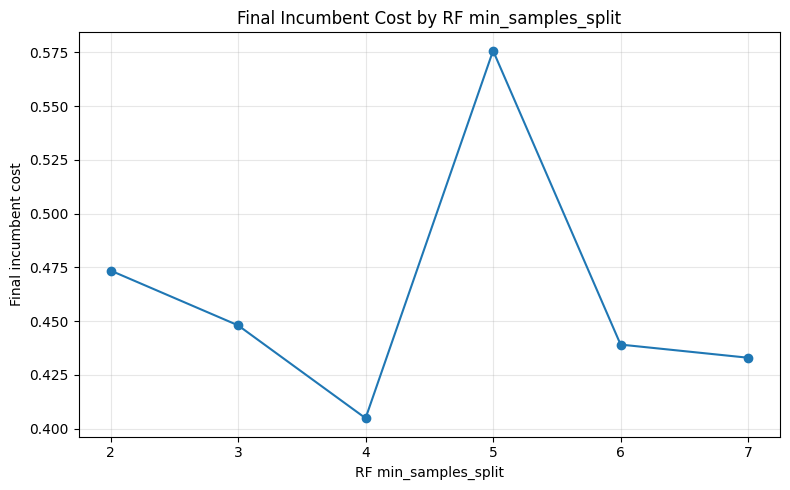

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    summary_df["min_samples_split"],
    summary_df["incumbent_cost"],
    marker="o",
)

ax.set_title("Final Incumbent Cost by RF min_samples_split")
ax.set_xlabel("RF min_samples_split")
ax.set_ylabel("Final incumbent cost")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

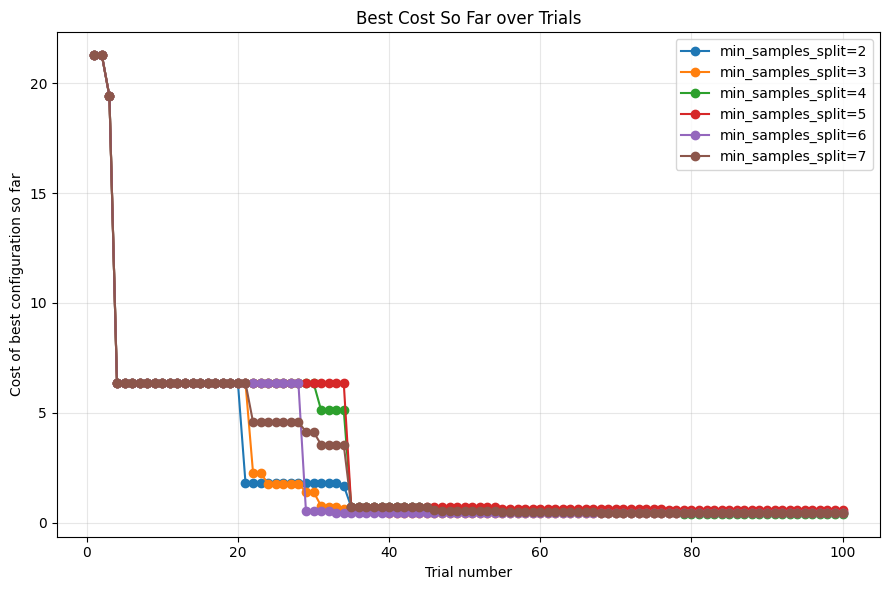

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))

for result in results:
    df = result["convergence"]
    min_split = result["min_samples_split"]

    ax.plot(
        df["trial"],
        df["best_so_far"],
        marker="o",
        label=f"min_samples_split={min_split}",
    )

ax.set_title("Best Cost So Far over Trials")
ax.set_xlabel("Trial number")
ax.set_ylabel("Cost of best configuration so far")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()